# Búsqueda del mejor umbral (threshold) para F1 Macro

A partir del fichero de probabilidades sobre dev generado en `03_sensorial_nn_classifier.ipynb`, se barre un amplio rango de umbrales y se selecciona el que maximiza la **F1 Macro**. Además, se muestra el **Accuracy** correspondiente.

## Fichero de entrada
```
predictions/BeingChillingWeWillWin_MLPsensorial_probs_dev.json
```
Cada entrada tiene la forma:
```json
{
  "id": "111904",
  "prob_YES": 0.40503,
  "label": "YES"
}
```

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score

## 1. Cargar las predicciones de dev

In [2]:
PROBS_DEV_PATH = '../predictions/BeingChillingWeWillWin_MLPsensorial_probs_dev.json'

with open(PROBS_DEV_PATH, 'r', encoding='utf-8') as f:
    probs_dev = json.load(f)

print(f'Número de muestras en dev: {len(probs_dev)}')
print(f'Ejemplo: {probs_dev[0]}')

Número de muestras en dev: 537
Ejemplo: {'id': '111904', 'prob_YES': 0.40503, 'label': 'YES'}


In [3]:
# Extraer prob_YES y las etiquetas reales (gold labels)
prob_yes = np.array([item['prob_YES'] for item in probs_dev])
gold_labels = np.array([item['label'] for item in probs_dev])  # 'YES' / 'NO'

# Convertir gold labels a binario: YES -> 1, NO -> 0
gold_binary = (gold_labels == 'YES').astype(int)

print(f'Distribución gold: YES={gold_binary.sum()}, NO={(1 - gold_binary).sum()}')
print(f'prob_YES — min: {prob_yes.min():.4f}, max: {prob_yes.max():.4f}, mean: {prob_yes.mean():.4f}')

Distribución gold: YES=321, NO=216
prob_YES — min: 0.3385, max: 0.7378, mean: 0.5436


## 2. Barrido de umbrales

Para cada umbral $t \in [0.01, 0.99]$ (con paso de 0.01):
- Si `prob_YES >= t` → predicción = YES (1)
- En otro caso → predicción = NO (0)

Se calcula **F1 Macro** y **Accuracy** en cada punto.

In [4]:
thresholds = np.arange(0.01, 1.00, 0.01)

f1_scores = []
acc_scores = []

for t in thresholds:
    preds = (prob_yes >= t).astype(int)
    f1 = f1_score(gold_binary, preds, average='macro')
    acc = accuracy_score(gold_binary, preds)
    f1_scores.append(f1)
    acc_scores.append(acc)

f1_scores = np.array(f1_scores)
acc_scores = np.array(acc_scores)

# Mejor umbral según F1 Macro
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_acc = acc_scores[best_idx]

print(f'Mejor umbral:     {best_threshold:.2f}')
print(f'F1 Macro:         {best_f1:.4f}')
print(f'Accuracy:         {best_acc:.4f}')

Mejor umbral:     0.55
F1 Macro:         0.5706
Accuracy:         0.5717


## 3. Visualización

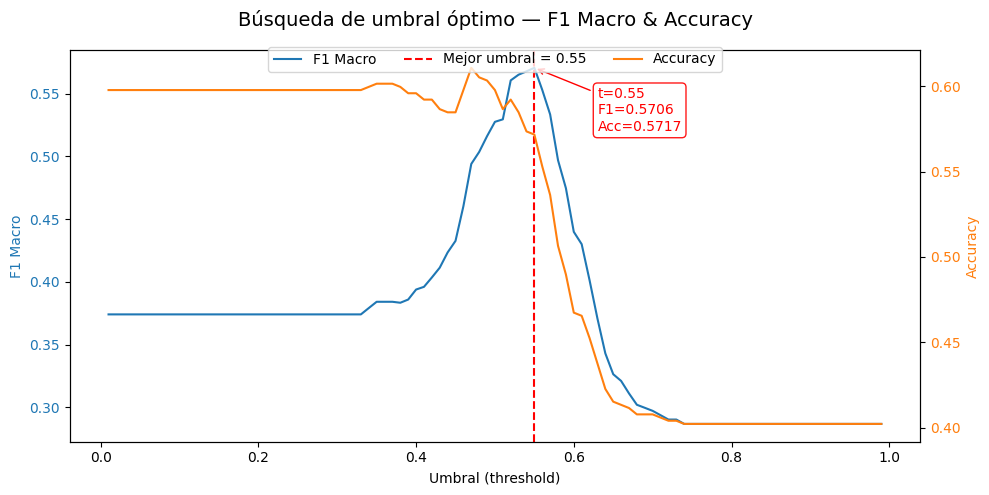

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color_f1 = 'tab:blue'
color_acc = 'tab:orange'

ax1.set_xlabel('Umbral (threshold)')
ax1.set_ylabel('F1 Macro', color=color_f1)
ax1.plot(thresholds, f1_scores, color=color_f1, label='F1 Macro')
ax1.tick_params(axis='y', labelcolor=color_f1)

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color=color_acc)
ax2.plot(thresholds, acc_scores, color=color_acc, label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color_acc)

# Marcar el mejor umbral
ax1.axvline(x=best_threshold, color='red', linestyle='--', linewidth=1.5,
            label=f'Mejor umbral = {best_threshold:.2f}')

# Anotar F1 y Accuracy en el mejor umbral
ax1.annotate(
    f't={best_threshold:.2f}\nF1={best_f1:.4f}\nAcc={best_acc:.4f}',
    xy=(best_threshold, best_f1),
    xytext=(best_threshold + 0.08, best_f1 - 0.05),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10, color='red',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.9)
)

fig.suptitle('Búsqueda de umbral óptimo — F1 Macro & Accuracy', fontsize=14)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=3)
fig.tight_layout()
plt.show()

## 4. Resumen

La tabla siguiente muestra los 10 mejores umbrales junto con sus scores:

In [6]:
import pandas as pd

results_df = pd.DataFrame({
    'threshold': thresholds,
    'f1_macro': f1_scores,
    'accuracy': acc_scores
})

top10 = results_df.sort_values('f1_macro', ascending=False).head(10).reset_index(drop=True)
top10.index += 1
top10.index.name = 'rank'
top10

,threshold,f1_macro,accuracy
rank,,,
1,0.55,0.570609,0.571695
2,0.54,0.567795,0.573557
3,0.53,0.565132,0.584730
4,0.52,0.560581,0.592179
5,0.56,0.552997,0.553073
6,0.57,0.533459,0.536313
7,0.51,0.529542,0.586592
8,0.50,0.527566,0.597765
9,0.49,0.516124,0.603352
